In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

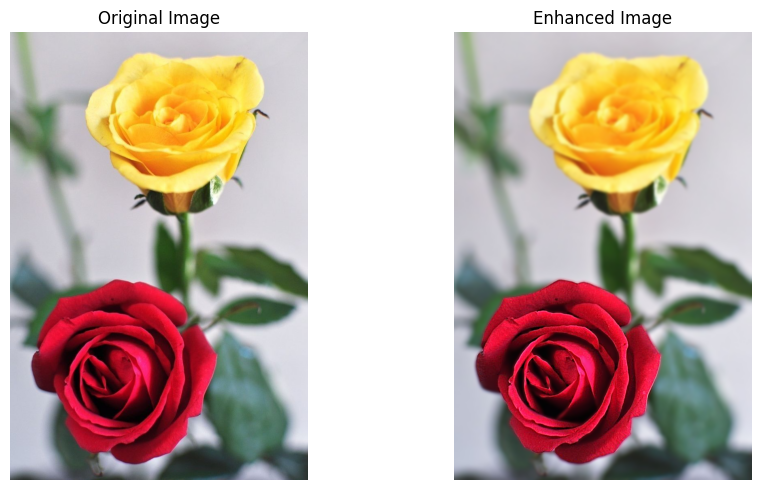

array([[[192, 194, 190],
        [191, 194, 190],
        [191, 193, 189],
        ...,
        [214, 207, 210],
        [214, 207, 210],
        [214, 207, 210]],

       [[192, 194, 190],
        [191, 194, 190],
        [191, 193, 189],
        ...,
        [214, 207, 210],
        [214, 207, 210],
        [214, 207, 210]],

       [[192, 194, 190],
        [192, 194, 190],
        [191, 193, 189],
        ...,
        [214, 207, 210],
        [214, 207, 210],
        [214, 207, 210]],

       ...,

       [[ 91,  86,  81],
        [ 90,  86,  80],
        [ 90,  86,  80],
        ...,
        [ 51,  53,  45],
        [ 50,  53,  44],
        [ 50,  53,  44]],

       [[ 88,  84,  79],
        [ 88,  84,  79],
        [ 87,  83,  78],
        ...,
        [ 51,  54,  45],
        [ 50,  53,  44],
        [ 50,  53,  44]],

       [[ 87,  83,  78],
        [ 87,  83,  78],
        [ 86,  83,  77],
        ...,
        [ 51,  54,  45],
        [ 50,  53,  44],
        [ 50,  53,  44]]

In [11]:
# Selective Object Enhancement (Color-Based Editing Tool)
# Needed for HSV multiple colors better.
COLOR_RANGES = {
    "red":    ([0,   100, 70],  [8,   255, 255], [170, 100, 70],  [179, 255, 255]),
    "yellow": ([20,  100, 100], [35,  255, 255]),
    "blue":   ([100, 80,  50],  [140, 255, 255]),
    "green":  ([36,  50,  50],  [85,  255, 255]),
    "orange": ([8,   120, 80],  [20,  255, 255]),
    "purple": ([125, 50,  50],  [155, 255, 255]),
}

def build_mask(image, color):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    ranges = COLOR_RANGES[color]
    
    if color == "red":
        mask1 = cv2.inRange(hsv, np.array(ranges[0]), np.array(ranges[1]))
        mask2 = cv2.inRange(hsv, np.array(ranges[2]), np.array(ranges[3]))
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        mask = cv2.inRange(hsv, np.array(ranges[0]), np.array(ranges[1]))
    # Best for natural objects
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Some noise might remain; Gaussian blur will remove it. (Probably lol)
    mask = cv2.GaussianBlur(mask,(7,7),0)
    return mask

def apply_enhancement(image, enhancement, strength =1.0):
    img = image.copy()
    
    if enhancement == "blur":
        ker = max(1, int(15* strength)) | 1 # Guarntees that it remains odd.
        img = cv2.GaussianBlur(img, (ker, ker), 0)
    
    elif enhancement =="sharpen":
        blurred = cv2.GaussianBlur(img, (0,0), 2.0)
        img = cv2.addWeighted(img, 1+1.5*strength, blurred, -1.5*strength, 0)
        img = np.clip(img,0,255).astype(np.uint8)
    
    elif enhancement == "grayscale":
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # ADD MORE IF NEEDED LATER
    return img

def selective_enhance(image_path , target_color = "red", target_enhancement="sharpen", background_enhancement="blur",
                      target_strength=1.0, bg_strength=1.0, show=True):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load: {image_path}")
    
    mask = build_mask(image, target_color)
    alpha = mask.astype(np.float32)[..., np.newaxis] / 255.0 # Mask values between 0 and 1

    
    fg = apply_enhancement(image, target_enhancement, target_strength).astype(np.float32)
    bg = apply_enhancement(image, background_enhancement, bg_strength).astype(np.float32)
    
    result = np.clip(fg * alpha + bg * (1 - alpha), 0, 255).astype(np.uint8) # Weighted average per pixel.
    if show:
        
        original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        result_rgb   = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_rgb)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(result_rgb)
        plt.title("Enhanced Image")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return result

selective_enhance(
    "red_yellow.jpg",
    target_color="red",
    target_enhancement="sharpen",
    background_enhancement="blur"
)